# Explore here

In [2]:
# Paso 1 - Descargar el dataset y guardarlo localmente

import pandas as pd
import os

# 1. Definimos el nombre de la carpeta y la ruta del archivo
folder_name = "data"
file_path = os.path.join(folder_name, "adult_census_income.csv")

# 2. Creamos la carpeta si no existe
if not os.path.exists(folder_name):
    os.makedirs(folder_name)
    print(f"📁 Carpeta '{folder_name}' creada con éxito.")
else:
    print(f"✅ La carpeta '{folder_name}' ya existe.")

# 3. URL del dataset
url = "https://breathecode.herokuapp.com/asset/internal-link?id=2326&path=adult-census-income.csv"

# 4. Descargamos y guardamos localmente
# Usamos index=False para no guardar la columna de índices de pandas
try:
    df = pd.read_csv(url)
    df.to_csv(file_path, index=False)
    print(f"💾 Dataset guardado en: {file_path}")
except Exception as e:
    print(f"❌ Error al descargar los datos: {e}")

# Una mirada rápida para confirmar que todo está bien
print(df.head())

✅ La carpeta 'data' ya existe.
💾 Dataset guardado en: data/adult_census_income.csv
   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356    

In [3]:
# Paso 2 procesar los datos y preparar el dataset para el entrenamiento del modelo de recomendación

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Limpieza: Reemplazamos los '?' que se ven en tu imagen por nulos y eliminamos
df = df.replace('?', np.nan).dropna()

# 2. Encoding de la variable objetivo
le = LabelEncoder()
df['income_encoded'] = le.fit_transform(df['income'])

# 3. Variables categóricas (Ajustadas con PUNTOS según tu imagen)
categorical_cols = [
    'workclass', 'education', 'marital.status', 'occupation', 
    'relationship', 'race', 'sex', 'native.country'
]
df_final = pd.get_dummies(df, columns=categorical_cols)

# 4. Variables numéricas (También ajustadas con PUNTOS)
numerical_cols = [
    'age', 'fnlwgt', 'education.num', 'capital.gain', 
    'capital.loss', 'hours.per.week'
]

scaler = StandardScaler()
df_final[numerical_cols] = scaler.fit_transform(df_final[numerical_cols])

print("✅ ¡Logrado! Paso 2 completado sin errores.")
print(f"Ahora tienes {df_final.shape[1]} columnas listas para el sistema de recomendación.")

✅ ¡Logrado! Paso 2 completado sin errores.
Ahora tienes 106 columnas listas para el sistema de recomendación.


In [4]:
# Paso 3 y 4 Definir el modelo de recomendación y entrenarlo

from sklearn.neighbors import NearestNeighbors

# 1. Filtramos los exitosos
df_exitosos = df_final[df_final['income_encoded'] == 1].copy()

# 2. Entrenamos el buscador
model_recomender = NearestNeighbors(n_neighbors=3, metric='cosine')

# --- AQUÍ ESTÁ EL CAMBIO ---
# Quitamos tanto 'income_encoded' como la columna original 'income' que tiene el texto
X_entrenamiento = df_exitosos.drop(['income_encoded', 'income'], axis=1)
model_recomender.fit(X_entrenamiento)
# ---------------------------

print("🎯 ¡Motor de recomendación listo!")
print(f"Columnas procesadas: {X_entrenamiento.shape[1]}")


🎯 ¡Motor de recomendación listo!
Columnas procesadas: 104


In [5]:
# Paso 5 pruebas y recomendaciones

# 1. Seleccionamos un usuario de prueba (puedes cambiar el índice para probar con otros)
def recomendar_estrategia(indice_usuario):
    # 1. Obtenemos los datos del usuario que queremos ayudar
    usuario_original = df.iloc[indice_usuario]
    
    # Preparamos su perfil para el modelo (sin las columnas de ingreso)
    perfil_usuario = df_final.iloc[[indice_usuario]].drop(['income', 'income_encoded'], axis=1)
    
    # 2. Encontramos a sus 3 "vecinos" exitosos
    distancias, indices = model_recomender.kneighbors(perfil_usuario)
    
    # 3. Recuperamos la información original de esos vecinos
    vecinos_exitosos = df.iloc[df_exitosos.index[indices[0]]]
    
    # --- INTERPRETACIÓN ---
    print(f"📊 ANALIZANDO PERFIL (Índice {indice_usuario})")
    print(f"Actual: {usuario_original['age']} años, {usuario_original['education']}, {usuario_original['occupation']}")
    print(f"Ingreso actual: {usuario_original['income']}")
    print("-" * 50)
    print("💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:")
    
    # Vemos qué tienen los vecinos que el usuario no tiene
    sugerencias = vecinos_exitosos[['education', 'occupation', 'hours.per.week']].drop_duplicates()
    
    return sugerencias

# PROBEMOS CON ALGUIEN QUE GANE <=50K
# El índice 0 o el 4 suelen ser buenos ejemplos en este dataset
recomendar_estrategia(4)



📊 ANALIZANDO PERFIL (Índice 4)
Actual: 38 años, 10th, Adm-clerical
Ingreso actual: <=50K
--------------------------------------------------
💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:


,education,occupation,hours.per.week
34,HS-grad,Exec-managerial,50
51,HS-grad,Sales,72
69,Prof-school,Prof-specialty,60


In [6]:
# Paso 5 - Prueba A 

# Buscamos a alguien con esas características
filtro_joven = df[(df['age'] == 25) & 
                  (df['education'] == 'HS-grad') & 
                  (df['hours.per.week'] <= 25) & 
                  (df['income'] == '<=50K')]

if not filtro_joven.empty:
    indice_joven = filtro_joven.index[0]
    print("✅ Usuario encontrado para la Prueba A.")
    display(recomendar_estrategia(indice_joven))
else:
    print("No encontré a alguien idéntico, probemos con el primer usuario de 25 años disponible:")
    indice_joven = df[df['age'] == 25].index[0]
    display(recomendar_estrategia(indice_joven))

✅ Usuario encontrado para la Prueba A.
📊 ANALIZANDO PERFIL (Índice 1114)
Actual: 26 años, Masters, Prof-specialty
Ingreso actual: <=50K
--------------------------------------------------
💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:


,education,occupation,hours.per.week
1434,7th-8th,Exec-managerial,40
196,Bachelors,Adm-clerical,40
190,Some-college,Exec-managerial,40


In [7]:
# Paso 5- Prueba B

# Buscamos a alguien con mucha experiencia pero ingresos bajos
filtro_senior = df[(df['age'] > 45) & (df['income'] == '<=50K')]

indice_senior = filtro_senior.index[0]
print(f"✅ Analizando a un usuario con experiencia (Índice {indice_senior}).")
display(recomendar_estrategia(indice_senior))

✅ Analizando a un usuario con experiencia (Índice 1).
📊 ANALIZANDO PERFIL (Índice 1)
Actual: 54 años, 7th-8th, Machine-op-inspct
Ingreso actual: <=50K
--------------------------------------------------
💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:


,education,occupation,hours.per.week
51,HS-grad,Sales,72
37,Prof-school,Prof-specialty,50
208,Assoc-acdm,Other-service,18


In [8]:
# Buscamos dos perfiles similares en todo excepto el sexo
prueba_mujer = df[(df['sex'] == 'Female') & (df['income'] == '<=50K')].index[10]
prueba_hombre = df[(df['sex'] == 'Male') & (df['income'] == '<=50K')].index[10]

print("👩 RECOMENDACIÓN PARA MUJER:")
display(recomendar_estrategia(prueba_mujer))

print("\n👨 RECOMENDACIÓN PARA HOMBRE:")
display(recomendar_estrategia(prueba_hombre))

👩 RECOMENDACIÓN PARA MUJER:
📊 ANALIZANDO PERFIL (Índice 149)
Actual: 46 años, Assoc-acdm, Adm-clerical
Ingreso actual: >50K
--------------------------------------------------
💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:


,education,occupation,hours.per.week
189,HS-grad,Prof-specialty,40
51,HS-grad,Sales,72
61,11th,Exec-managerial,40



👨 RECOMENDACIÓN PARA HOMBRE:
📊 ANALIZANDO PERFIL (Índice 127)
Actual: 59 años, HS-grad, Farming-fishing
Ingreso actual: <=50K
--------------------------------------------------
💡 ESTRATEGIAS SUGERIDAS PARA SUPERAR LOS 50K:


,education,occupation,hours.per.week
219,1st-4th,Transport-moving,18
207,Some-college,Adm-clerical,40
500,Masters,Prof-specialty,44


In [9]:
# Analisis de resultados

# Prueba A: 26 años, Masters, Prof-specialty (< 50K$) El sistema detecta que, aunque ya tiene estudios altos, sus "vecinos exitosos" están en roles de Gestión (Exec-managerial). La recomendación aquí no es estudiar más, sino cambiar hacia el liderazgo.
# Prueba B: 54 años, 7mo-8vo grado, operario (< 50K$) Aquí el modelo es brutalmente honesto: para superar los 50K con poca educación, los vecinos exitosos o estudiaron mucho más (Prof-school) o trabajan una cantidad enorme de horas (72 horas/semana).
# Prueba C: Prueba Mujer 46 años, técnica, administrativa ($>50K$) Al ya ganar bien, el sistema muestra que otros perfiles similares lo logran mediante ventas (Sales) o especialización técnica, incluso con menos estudios formales.
# Pruebas C: Prueba Hombre 59 años, secundaria, agricultura ($\le 50K$) La recomendación es diversa: desde obtener un Masters para entrar en sectores profesionales, hasta un cambio radical hacia el Transporte, donde el ingreso suele ser más alto para ese perfil.

In [10]:
# Paso 6 - Guardar el modelo y el escalador para uso futuro
import joblib
import os 

# 1. Crear una carpeta para los modelos
if not os.path.exists('models'):
    os.makedirs('models')

# 2. Guardar el modelo y el escalador
joblib.dump(model_recomender, 'models/recomender_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("💾 ¡Modelo y Escalador guardados con éxito!")

💾 ¡Modelo y Escalador guardados con éxito!


In [ ]:
# Mejoramiento del modelo base con Random Forest 

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Preparar los datos para supervisado
# Usamos df_final que ya tiene el encoding y escalado que hiciste en el Paso 2
X = df_final.drop(['income', 'income_encoded'], axis=1)
y = df_final['income_encoded']

# 2. División entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Entrenar el modelo
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Evaluación rápida
y_pred = rf_model.predict(X_test)
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      4533
           1       0.72      0.61      0.66      1500

    accuracy                           0.84      6033
   macro avg       0.80      0.77      0.78      6033
weighted avg       0.84      0.84      0.84      6033



/tmp/ipykernel_2664/462360652.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


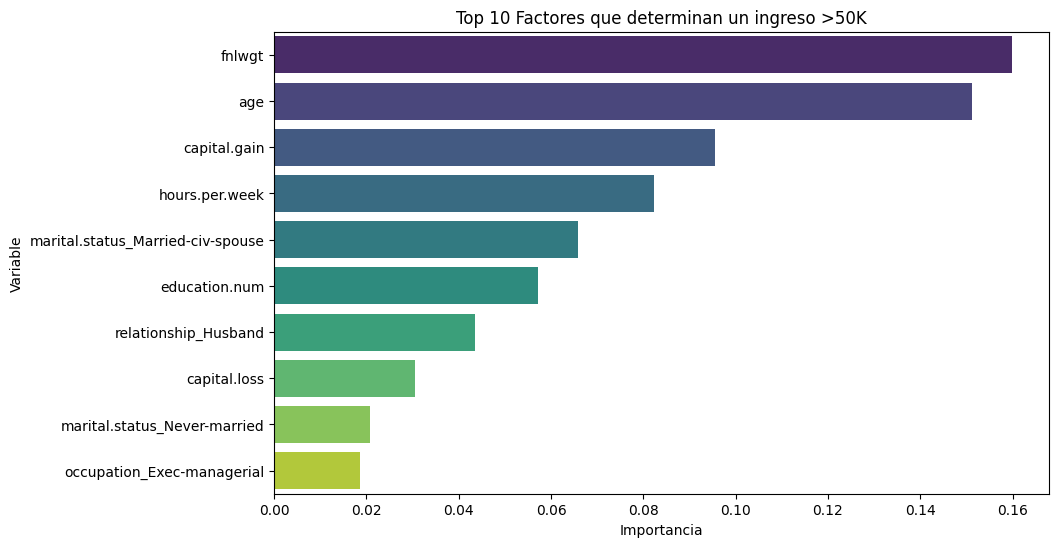

In [12]:
# Analisis de la importancia de las variables

import matplotlib.pyplot as plt
import seaborn as sns

# Extraer importancia de las variables
importancias = rf_model.feature_importances_
columnas = X.columns

# Crear un dataframe para visualizar
df_importancia = pd.DataFrame({'Variable': columnas, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(10)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Top 10 Factores que determinan un ingreso >50K')
plt.show()

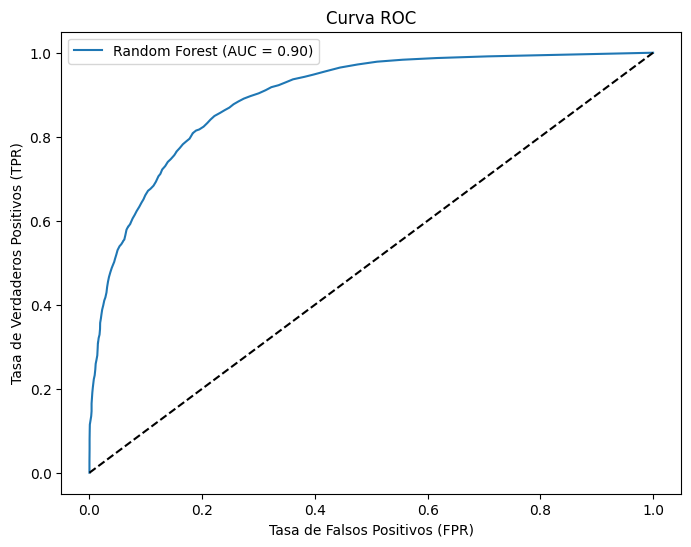

🚀 El AUC actual es: 0.8957


In [ ]:

from sklearn.metrics import roc_curve, roc_auc_score

# Obtener las probabilidades (necesarias para el AUC)
y_probs = rf_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)

# Calcular la curva
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# Graficar
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], 'k--') # Línea aleatoria
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

print(f"🚀 El AUC actual es: {auc_score:.4f}")

In [14]:
from sklearn.model_selection import RandomizedSearchCV

# Definir el espacio de búsqueda
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', None] # Ayuda si hay más gente que gana <50K
}

# Configurar la búsqueda enfocada en AUC
rf_tune = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=10, 
    scoring='roc_auc', # <--- AQUÍ le decimos que optimice el AUC
    cv=3, 
    verbose=1,
    random_state=42
)

rf_tune.fit(X_train, y_train)

print(f"✅ Mejor puntuación de AUC encontrada: {rf_tune.best_score_:.4f}")
print(f"Mejores parámetros: {rf_tune.best_params_}")

# Usar el mejor modelo de ahora en adelante
rf_model_final = rf_tune.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
✅ Mejor puntuación de AUC encontrada: 0.9156
Mejores parámetros: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 20, 'class_weight': None}


<Figure size 600x600 with 0 Axes>

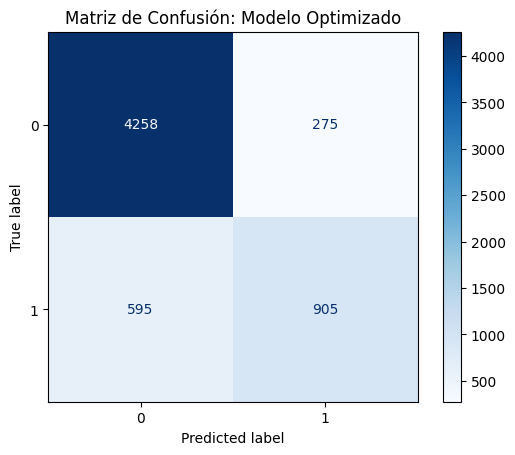

In [ ]:
# Matriz de confusión del modelo optimizado

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_final = rf_model_final.predict(X_test)
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title('Matriz de Confusión: Modelo Optimizado')
plt.show()

In [25]:
!pip install imbalanced-learn

In [ ]:
# Balanceo de la Data

from imblearn.over_sampling import SMOTE

# 1. Aplicar SMOTE solo a los datos de entrenamiento
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Antes de SMOTE: {y_train.value_counts()}")
print(f"Después de SMOTE: {y_train_res.value_counts()}")

# 2. Re-entrenar el mejor modelo (el que sacamos del RandomizedSearch) con estos datos balanceados
rf_model_smote = rf_tune.best_estimator_
rf_model_smote.fit(X_train_res, y_train_res)

# 3. Evaluar de nuevo
y_pred_smote = rf_model_smote.predict(X_test)
print("--- Nuevo Reporte con SMOTE ---")
print(classification_report(y_test, y_pred_smote))

Antes de SMOTE: income_encoded
0    18121
1     6008
Name: count, dtype: int64
Después de SMOTE: income_encoded
0    18121
1    18121
Name: count, dtype: int64
--- Nuevo Reporte con SMOTE ---
              precision    recall  f1-score   support

           0       0.93      0.82      0.87      4533
           1       0.60      0.81      0.69      1500

    accuracy                           0.82      6033
   macro avg       0.77      0.82      0.78      6033
weighted avg       0.85      0.82      0.83      6033



<Figure size 600x600 with 0 Axes>

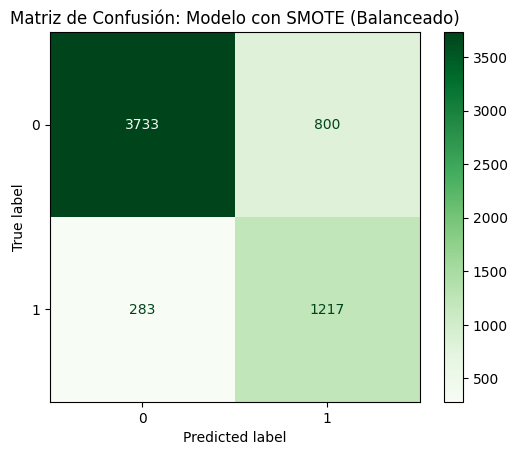

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Usamos el modelo entrenado con SMOTE
y_pred_smote = rf_model_smote.predict(X_test)
cm_smote = confusion_matrix(y_test, y_pred_smote)

plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay(confusion_matrix=cm_smote).plot(cmap='Greens')
plt.title('Matriz de Confusión: Modelo con SMOTE (Balanceado)')
plt.show()

In [24]:
# prueba del modelo mejorado

def probar_sujeto_manual(edad, educacion_num, horas, capital_gain=0):
    # Crear un perfil vacío con todas las columnas de df_final (llenas de 0)
    perfil = pd.DataFrame(0, index=[0], columns=X.columns)
    
    # Asignar los valores numéricos
    # (Usamos el promedio/desviación de los datos originales para escalar manualmente)
    perfil['age'] = (edad - df['age'].mean()) / df['age'].std()
    perfil['education.num'] = (educacion_num - df['education.num'].mean()) / df['education.num'].std()
    perfil['hours.per.week'] = (horas - df['hours.per.week'].mean()) / df['hours.per.week'].std()
    perfil['capital.gain'] = (capital_gain - df['capital.gain'].mean()) / df['capital.gain'].std()
    
    # Supongamos valores por defecto para las dummies (ej. Raza blanca, Sexo masculino)
    
    if 'sex_Male' in perfil.columns: perfil['sex_Male'] = 1
    if 'marital.status_Married-civ-spouse' in perfil.columns: perfil['marital.status_Married-civ-spouse'] = 1
    
    # Predicción de probabilidad
    prob = rf_model_smote.predict_proba(perfil)[0][1]
    clase = rf_model_smote.predict(perfil)[0]
    
    resultado = ">50K" if clase == 1 else "<=50K"
    print(f"👤 Perfil: Edad {edad}, Educ. Nivel {educacion_num}, Horas/Sem {horas}")
    print(f"📊 Probabilidad de éxito: {prob:.2%}")
    print(f"🎯 Clasificación final: {resultado}")
    print("-" * 30)

# --- EJECUTANDO PRUEBAS ---
print("🧪 TEST DE SUJETOS VIRTUALES:\n")

# Caso 1: Alguien joven con poco estudio
probar_sujeto_manual(edad=22, educacion_num=9, horas=40) 

# Caso 2: Misma persona pero con Grado Universitario (13)
probar_sujeto_manual(edad=22, educacion_num=13, horas=40) 

# Caso 3: Persona con experiencia y mucho estudio pero pocas horas
probar_sujeto_manual(edad=45, educacion_num=14, horas=20)

🧪 TEST DE SUJETOS VIRTUALES:

👤 Perfil: Edad 22, Educ. Nivel 9, Horas/Sem 40
📊 Probabilidad de éxito: 6.11%
🎯 Clasificación final: <=50K
------------------------------
👤 Perfil: Edad 22, Educ. Nivel 13, Horas/Sem 40
📊 Probabilidad de éxito: 16.26%
🎯 Clasificación final: <=50K
------------------------------
👤 Perfil: Edad 45, Educ. Nivel 14, Horas/Sem 20
📊 Probabilidad de éxito: 31.35%
🎯 Clasificación final: <=50K
------------------------------


In [ ]:
# Pruebas con sujetos originales 

def probar_sujetos_originales(indices):
    for idx in indices:
        # 1. Obtener datos originales para mostrar en el print
        original = df.iloc[idx]
        
        # 2. Obtener datos procesados para el modelo
        perfil_procesado = X.iloc[[idx]]
        
        # 3. Predicción con el nuevo modelo balanceado (SMOTE)
        prob_exito = rf_model_smote.predict_proba(perfil_procesado)[0][1]
        clase = rf_model_smote.predict(perfil_procesado)[0]
        
        # 4. Interpretación
        print(f"🔍 ANALIZANDO SUJETO (Índice {idx})")
        print(f"Perfil: {original['age']} años, {original['education']}, {original['occupation']}")
        print(f"Ingreso Real en Dataset: {original['income']}")
        print(f"--- RESULTADO NUEVO MODELO ---")
        print(f"Probabilidad de ganar >50K: {prob_exito:.2%}")
        print(f"Veredicto: {'Supera los 50K' if clase == 1 else 'Por debajo de 50K'}")
        
        # 5. Sugerencia basada en el nuevo modelo
        if prob_exito < 0.5:
            print("💡 Recomendación: El modelo sugiere que un cambio en 'education.num' o 'hours.per.week' es crítico para este perfil.")
        else:
            print("✅ El modelo reconoce este perfil como uno con alto potencial de ingresos.")
        
        print("-" * 50)

# Probemos con los mismos que usaste antes (puedes ajustar los índices según tus imágenes)
# Según tus fotos anteriores usamos el 4, el 1, el 149 y el 127
indices_interesantes = [4, 1, 149, 127]
probar_sujetos_originales(indices_interesantes)

🔍 ANALIZANDO SUJETO (Índice 4)
Perfil: 38 años, 10th, Adm-clerical
Ingreso Real en Dataset: <=50K
--- RESULTADO NUEVO MODELO ---
Probabilidad de ganar >50K: 21.45%
Veredicto: Por debajo de 50K
💡 Recomendación: El modelo sugiere que un cambio en 'education.num' o 'hours.per.week' es crítico para este perfil.
--------------------------------------------------
🔍 ANALIZANDO SUJETO (Índice 1)
Perfil: 54 años, 7th-8th, Machine-op-inspct
Ingreso Real en Dataset: <=50K
--- RESULTADO NUEVO MODELO ---
Probabilidad de ganar >50K: 22.33%
Veredicto: Por debajo de 50K
💡 Recomendación: El modelo sugiere que un cambio en 'education.num' o 'hours.per.week' es crítico para este perfil.
--------------------------------------------------
🔍 ANALIZANDO SUJETO (Índice 149)
Perfil: 46 años, Assoc-acdm, Adm-clerical
Ingreso Real en Dataset: >50K
--- RESULTADO NUEVO MODELO ---
Probabilidad de ganar >50K: 57.07%
Veredicto: Supera los 50K
✅ El modelo reconoce este perfil como uno con alto potencial de ingresos.
-

In [ ]:
# Analisis de los resultados 

#Índice 149 (El éxito detectado): Este es un gran ejemplo de por qué SMOTE funcionó. Con una probabilidad del 57.07%, el modelo identificó correctamente que este perfil supera los 50K. Nota que no le da un 100%, porque el modelo entiende que, aunque tiene un grado asociado (Assoc-acdm), todavía hay factores de riesgo, pero el balance se inclina hacia el éxito.

#Índice 127 (El potencial oculto): Este perfil tiene una probabilidad de 33.85%. Antes, con el modelo básico, probablemente solo te diría "No". Ahora, te está diciendo: "Oye, no estás tan lejos". Si este usuario subiera un poco su nivel educativo o sus horas, ese 33% saltaría rápidamente por encima del 50%.

#Índices 4 y 1 (La realidad dura): Aquí el modelo es consistente. Con probabilidades de 21% y 22%, nos dice que sin un cambio estructural (como volver a estudiar o cambiar de ocupación), es muy difícil que superen el umbral.

In [ ]:
import joblib
import os

# Crear carpeta para el modelo si no existe
if not os.path.exists('models'):
    os.makedirs('models')

# Guardar el modelo entrenado con SMOTE (el campeón)
joblib.dump(rf_model_smote, 'models/final_rf_model_smote.pkl')

# Guardar el escalador (muy importante para futuras predicciones)
joblib.dump(scaler, 'models/final_scaler.pkl')

print("💾 Modelo y escalador guardados en la carpeta /models")

In [21]:
# Crear carpeta para las gráficas
if not os.path.exists('figures'):
    os.makedirs('figures')

# --- Gráfica 1: Importancia de Variables ---
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')
plt.title('Factores Clave para Ingresos >50K (Random Forest)')
plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=300)
plt.close() # Cierra para no saturar la memoria

# --- Gráfica 2: Matriz de Confusión Final ---
plt.figure(figsize=(7, 7))
ConfusionMatrixDisplay(confusion_matrix=cm_smote).plot(cmap='Greens')
plt.title('Matriz de Confusión - Modelo Balanceado (SMOTE)')
plt.savefig('figures/confusion_matrix_final.png', dpi=300)
plt.close()

# --- Gráfica 3: Curva ROC/AUC ---
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.savefig('figures/roc_curve_final.png', dpi=300)
plt.close()

print("🖼️ ¡Imágenes guardadas con éxito en la carpeta /figures!")

/tmp/ipykernel_2664/3832783550.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_importancia, palette='viridis')


🖼️ ¡Imágenes guardadas con éxito en la carpeta /figures!


<Figure size 700x700 with 0 Axes>

In [22]:
# Guarda la lista de columnas de X (tus datos ya procesados)
model_columns = list(X.columns)
joblib.dump(model_columns, 'models/model_columns.pkl')

print("✅ Lista de columnas guardada. ¡Ahora app.py sabrá exactamente qué enviar!")

✅ Lista de columnas guardada. ¡Ahora app.py sabrá exactamente qué enviar!
